In [1]:
# importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
# load the dataset
df = pd.read_csv("/content/AmesHousing.csv")

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
# shape of dataset
print("Rows: ", df.shape[0]) # no of rows
print("Columns: ", df.shape[1]) # no of columns

Rows:  2930
Columns:  82


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
# statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [7]:
# checking missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


In [8]:
# missing values percentage calculation
missing_percent = (df.isnull().sum()/len(df)) * 100
missing_percent = missing_percent[missing_percent > 0]
missing_percent.sort_values(ascending = False)

,0
Pool QC,99.556314
Misc Feature,96.382253
Alley,93.242321
Fence,80.477816
Mas Vnr Type,60.580205
Fireplace Qu,48.532423
Lot Frontage,16.723549
Garage Qual,5.426621
Garage Cond,5.426621
Garage Yr Blt,5.426621


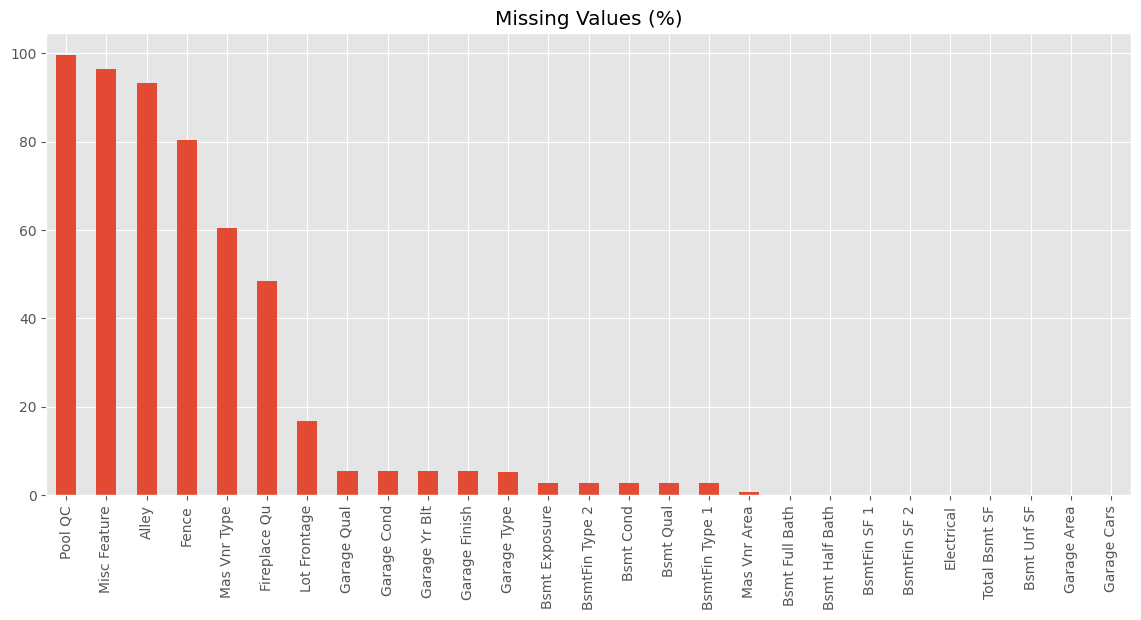

In [9]:
# plotting missing values
plt.figure(figsize=(14,6))
missing_percent.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values (%)")
plt.show()

In [10]:
# finding duplicate records
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


In [11]:
# finding numerical columns
num_cols = df.select_dtypes(include = np.number)
print(num_cols)

      Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0         1  526301100           20         141.0     31770             6   
1         2  526350040           20          80.0     11622             5   
2         3  526351010           20          81.0     14267             6   
3         4  526353030           20          93.0     11160             7   
4         5  527105010           60          74.0     13830             5   
...     ...        ...          ...           ...       ...           ...   
2925   2926  923275080           80          37.0      7937             6   
2926   2927  923276100           20           NaN      8885             5   
2927   2928  923400125           85          62.0     10441             5   
2928   2929  924100070           20          77.0     10010             5   
2929   2930  924151050           60          74.0      9627             7   

      Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  ...  \
0     

In [12]:
# finding categorical columns
cat_cols = df.select_dtypes(include = object)
print(cat_cols)

     MS Zoning Street Alley Lot Shape Land Contour Utilities Lot Config  \
0           RL   Pave   NaN       IR1          Lvl    AllPub     Corner   
1           RH   Pave   NaN       Reg          Lvl    AllPub     Inside   
2           RL   Pave   NaN       IR1          Lvl    AllPub     Corner   
3           RL   Pave   NaN       Reg          Lvl    AllPub     Corner   
4           RL   Pave   NaN       IR1          Lvl    AllPub     Inside   
...        ...    ...   ...       ...          ...       ...        ...   
2925        RL   Pave   NaN       IR1          Lvl    AllPub    CulDSac   
2926        RL   Pave   NaN       IR1          Low    AllPub     Inside   
2927        RL   Pave   NaN       Reg          Lvl    AllPub     Inside   
2928        RL   Pave   NaN       Reg          Lvl    AllPub     Inside   
2929        RL   Pave   NaN       Reg          Lvl    AllPub     Inside   

     Land Slope Neighborhood Condition 1  ... Garage Type Garage Finish  \
0           Gtl        N

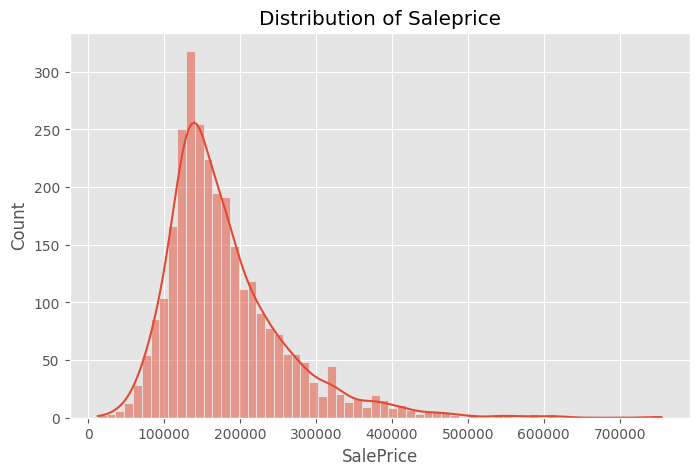

In [13]:
# Analyzing sale price: e.g. about 250 houses are in range from 100000 to 300000
plt.figure(figsize = (8, 5))
# sns.histplot(df["SalePrice"])
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Saleprice")
plt.show()

In [20]:
# v30
# box plot: A box plot (or box-and-whisker plot) visually summarizes numerical data through its quartiles.
# It displays a five-number summary: the minimum, first quartile (Q1), median, third quartile (Q3), and maximum.
# It is highly effective for identifying data spread, skewness, and outliers.

# Outliers: An outlier is a data point that differs significantly from the remaining observations in a dataset.

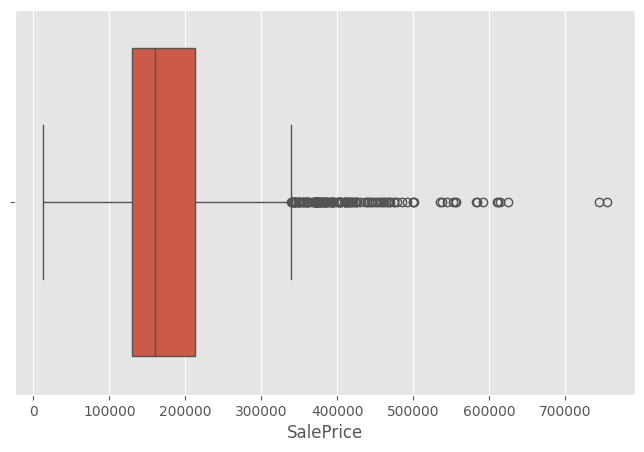

In [16]:
# box plot of the salesprice
plt.figure(figsize = (8,5))
sns.boxplot(x=df["SalePrice"])
plt.show()

In [19]:
# Correlated Features: Correlated features are variables within a dataset that share a strong mathematical relationship,
# meaning they change together in a predictable pattern. When two columns (features) move in the same direction
# (e.g., as house size increases, price increases), they are positively correlated. When they move in opposite directions,
# they are negatively correlated.

corr = df.corr(numeric_only = True)
corr['SalePrice'].sort_values(ascending = False).head(15)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


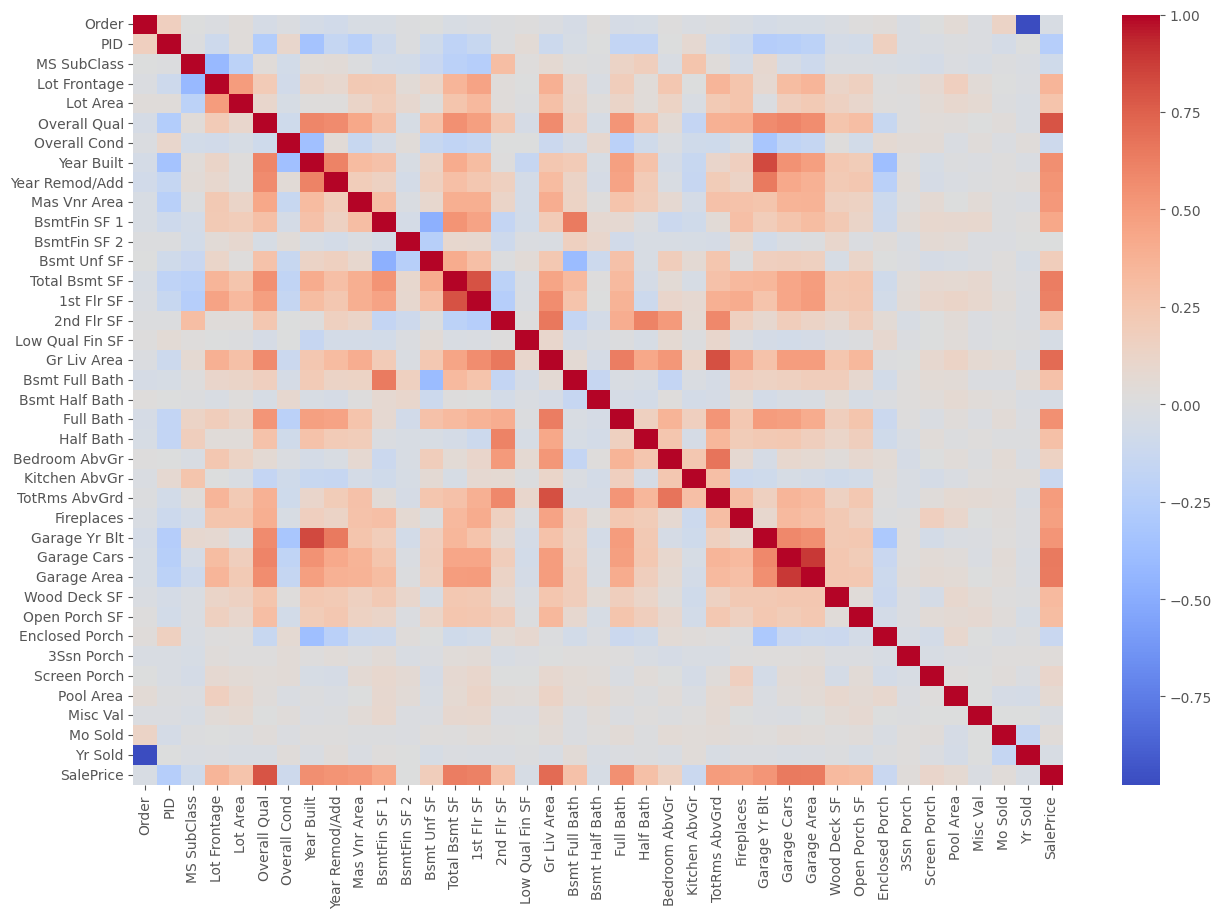

In [22]:
# Correlated heatmap: A correlation heatmap is a graphical visualization of a correlation matrix, using colored cells
# to represent the strength and direction of relationships between numerical variables. It is essential for feature s
# election and identifying multicollinearity (redundant variables) before training models.

# correlated heatmap
plt.figure(figsize = (15, 10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

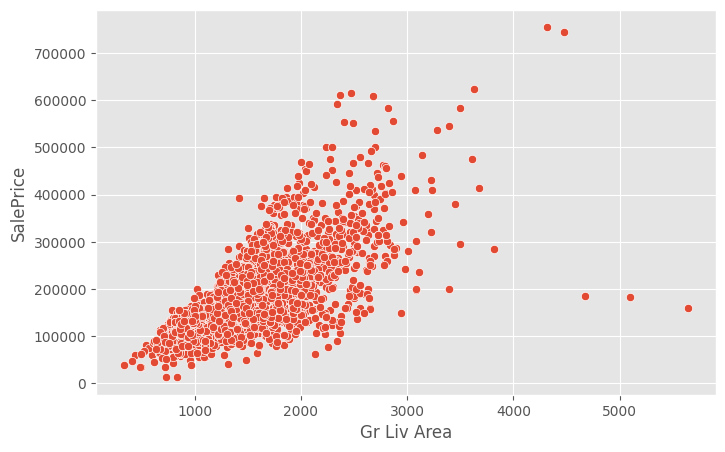

In [24]:
# scatter plot: A scatter plot is a 2D data visualization that uses dots to represent the relationship between
# two numerical variables. It is primarily used during Exploratory Data Analysis (EDA) and feature selection to identify
# correlations, spot clusters, and detect outliers.

# Scatter Plot
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "Gr Liv Area", y = "SalePrice")

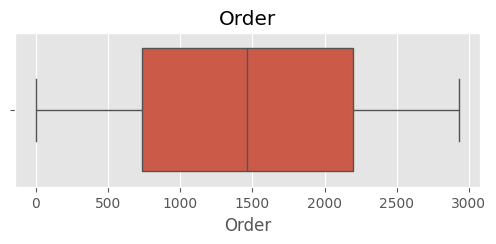

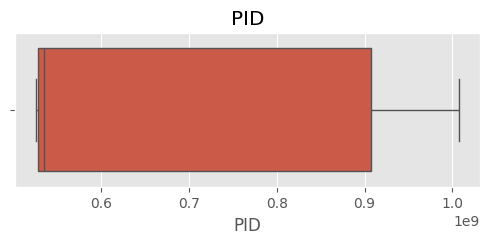

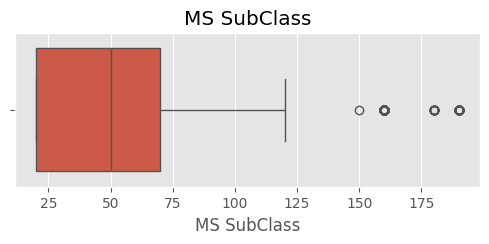

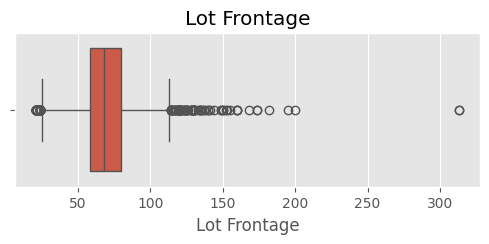

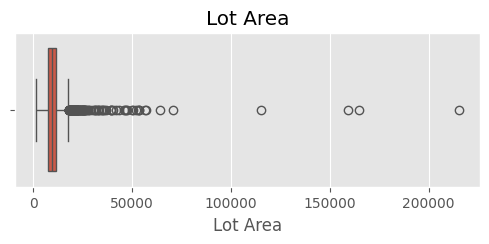

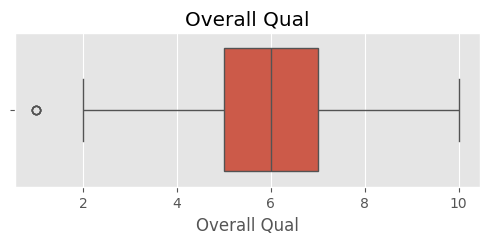

In [25]:
# Outlier Detection:

numeric = df.select_dtypes(include = np.number)
for col in numeric.columns[:6]:
  plt.figure(figsize = (6,2))
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()

In [ ]:
# EDA Summary
'''
  1. Dataset contains both numerical and categorical features.
  2. Missing values exist in multiple columns.
  3. SalePrice is righ-skewed.
  4. Overall Quality has the strongest positive correlation with SalePrice.
  5. Ground Living Area strongly affects price.
  6. Garage capacity increases house value.
  7. Some extreme outliers are present.
  8. Neighbourhood significantly impacts house prices.
  9. Several numerical vairables are highly correlated.
  10. Data requires preprocessing before machine learning.
'''

In [ ]:
# Data Pre-processing: Data preprocessing is the crucial first step in machine learning where raw, messy data is cleaned,
# formatted, and transformed into a usable structure.